In [1]:
import scanpy as sc
import gseapy as gp

## Pre-processing

In [2]:
adata = sc.read(
    "kang_counts_25k.h5ad", backup_url="https://figshare.com/ndownloader/files/34464122"
)
adata

AnnData object with n_obs × n_vars = 24673 × 15706
    obs: 'nCount_RNA', 'nFeature_RNA', 'tsne1', 'tsne2', 'label', 'cluster', 'cell_type', 'replicate', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.4', 'seurat_clusters'
    var: 'name'
    obsm: 'X_pca', 'X_umap'

In [3]:
# Storing the counts for later use
adata.X = adata.X.toarray()
# Renaming label to condition
adata.obs = adata.obs.rename({"label": "condition"}, axis=1)
adata.obs["group"] = adata.obs.condition.astype("string") + "_" + adata.obs.cell_type.astype("string")

# Normalizing
sc.pp.normalize_total(adata)
adata_norm = adata.copy()
sc.pp.log1p(adata)

In [4]:
adata.obs["group"].value_counts()

group
stim_CD4 T cells          5678
ctrl_CD4 T cells          5560
ctrl_CD14+ Monocytes      2932
stim_CD14+ Monocytes      2765
stim_B cells              1335
ctrl_B cells              1316
stim_NK cells              861
ctrl_NK cells              855
ctrl_CD8 T cells           811
stim_CD8 T cells           810
stim_FCGR3A+ Monocytes     569
ctrl_FCGR3A+ Monocytes     520
stim_Dendritic cells       271
ctrl_Dendritic cells       258
stim_Megakaryocytes         69
ctrl_Megakaryocytes         63
Name: count, dtype: Int64

In [5]:
# Take one condition
adata = adata[adata.obs['condition'] == 'ctrl']
adata.obs['condition'].value_counts()

condition
ctrl    12315
Name: count, dtype: int64

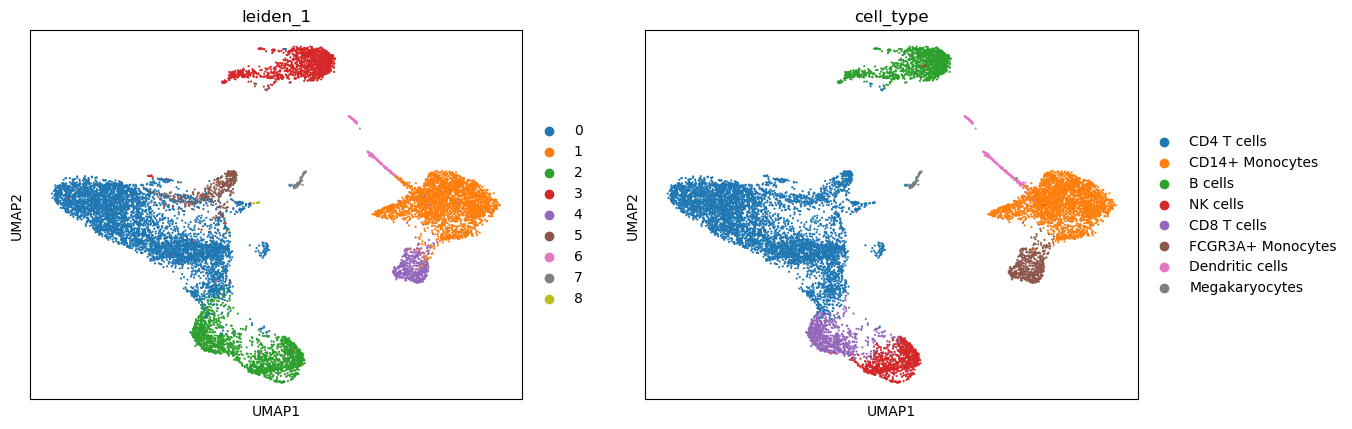

In [37]:
# # # Cluster
# sc.pp.pca(adata, n_comps=50)
# sc.pp.neighbors(adata, n_neighbors=10, use_rep="X_pca")
sc.tl.leiden(adata, resolution=.2, key_added="leiden_1")
sc.pl.umap(adata, color=['leiden_1', 'cell_type'])

In [38]:
sc.tl.rank_genes_groups(adata, "leiden_1", method="t-test",corr_method="bonferroni")

In [39]:
df_1 = sc.get.rank_genes_groups_df(adata, group="1")

In [40]:
df_1

,names,scores,logfoldchanges,pvals,pvals_adj
0,FTL,241.207672,4.929423,0.0,0.0
1,TIMP1,170.800476,5.314831,0.0,0.0
2,TYROBP,164.061905,4.509392,0.0,0.0
3,FTH1,153.688461,3.006548,0.0,0.0
4,CD63,142.165771,3.983320,0.0,0.0
...,...,...,...,...,...
15701,PTMA,-87.503670,-2.141405,0.0,0.0
15702,RPL21,-87.971542,-1.612308,0.0,0.0
15703,RPS6,-88.939507,-1.758607,0.0,0.0
15704,RPS19,-89.548676,-1.731019,0.0,0.0


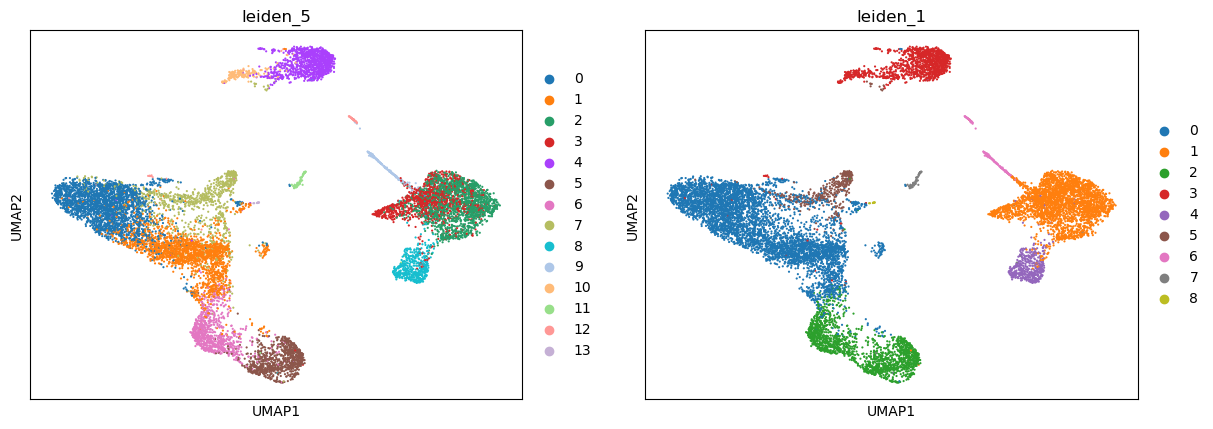

In [43]:
sc.tl.leiden(adata, resolution=1., key_added="leiden_5")
sc.pl.umap(adata, color=['leiden_5', 'leiden_1'])

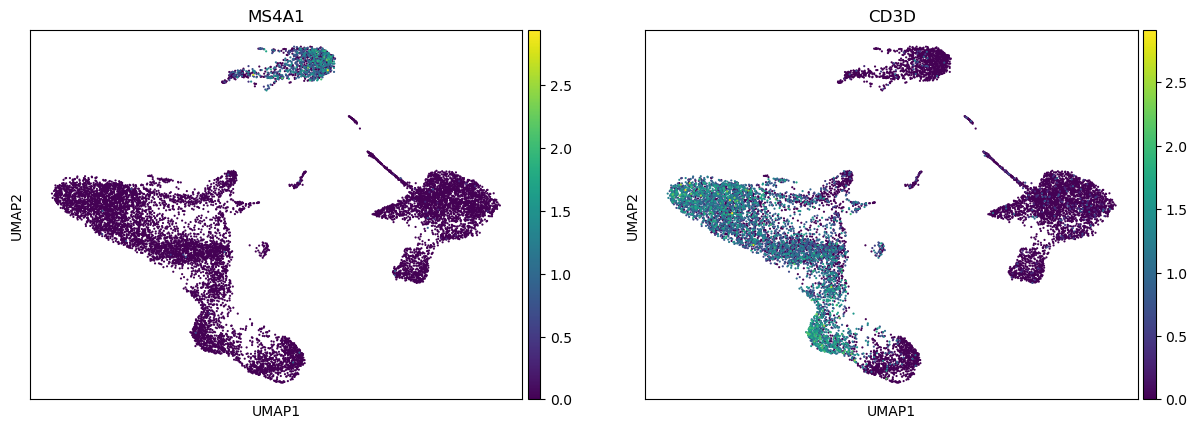

In [36]:
sc.pl.umap(adata, color=['MS4A1', 'CD3D'])

In [65]:
sc.tl.rank_genes_groups(adata, "leiden_5", method="t-test",corr_method="bonferroni")

In [ ]:
df_2_4 = sc.get.rank_genes_groups_df(adata, group="2",)
df_2_5 = sc.get.rank_genes_groups_df(adata, group="3", reference="2")

In [ ]:
df_2_4

,names,scores,logfoldchanges,pvals,pvals_adj
0,FTH1,26.161816,0.441580,1.604475e-131,2.519989e-127
1,IL8,25.463804,1.484910,1.110865e-126,1.744725e-122
2,CCL2,25.113811,2.622530,1.045773e-125,1.642492e-121
3,FTL,23.959843,0.596201,1.537075e-112,2.414130e-108
4,SOD2,21.084875,1.033180,8.039677e-91,1.262712e-86
...,...,...,...,...,...
15701,RPS18,-26.980070,-0.966931,1.054165e-140,1.655671e-136
15702,RPL32,-27.106071,-0.875186,2.807203e-142,4.408993e-138
15703,RPL13A,-28.583651,-0.906937,1.952218e-156,3.066154e-152
15704,RPS14,-29.929340,-0.994988,5.205766e-169,8.176175e-165


In [14]:
df_2_5

,names,scores,logfoldchanges,pvals,pvals_adj
0,CCL5,73.689713,5.006831,0.000000e+00,0.000000e+00
1,B2M,54.332668,0.807945,9.723212e-321,1.527128e-316
2,NKG7,51.413399,4.063129,1.438626e-270,2.259506e-266
3,TMSB4X,44.850739,0.913206,1.126043e-273,1.768563e-269
4,HLA-B,37.347893,0.914479,1.727079e-195,2.712550e-191
...,...,...,...,...,...
15701,TIMP1,-48.618496,-3.483137,0.000000e+00,0.000000e+00
15702,SPI1,-56.225479,-7.568307,0.000000e+00,0.000000e+00
15703,C15orf48,-58.963497,-5.502443,0.000000e+00,0.000000e+00
15704,CCR7,-59.068611,-4.540197,0.000000e+00,0.000000e+00


In [50]:
# Compare children with parent
from scipy.stats import wilcoxon, spearmanr, kendalltau, rankdata

# Find common genes between df_2_4 and df_1
genes_common = set(df_2_4["names"]) & set(df_1["names"])
genes_common = list(genes_common)

# Get the rank of each gene (1 = highest score)
ranks_2_4 = df_2_4.set_index("names").loc[genes_common, "scores"].rank(ascending=False)
ranks_1 = df_1.set_index("names").loc[genes_common, "scores"].rank(ascending=False)

# Compare the ranks using Spearman and Kendall rank correlation tests
spearman_corr, spearman_p = spearmanr(ranks_2_4, ranks_1)
kendall_corr, kendall_p = kendalltau(ranks_2_4, ranks_1)

print(f"Spearman rank correlation: {spearman_corr:.4f}, p-value: {spearman_p:.4e}")
print(f"Kendall tau correlation: {kendall_corr:.4f}, p-value: {kendall_p:.4e}")


Spearman rank correlation: 0.3179, p-value: 0.0000e+00
Kendall tau correlation: 0.2281, p-value: 0.0000e+00


In [16]:
# Compare children with parent
from scipy.stats import wilcoxon, spearmanr, kendalltau, rankdata

# Find common genes between df_2_5 and df_1
genes_common = set(df_2_5["names"]) & set(df_1["names"])
genes_common = list(genes_common)

# Get the rank of each gene (1 = highest score)
ranks_2_5 = df_2_5.set_index("names").loc[genes_common, "scores"].rank(ascending=False)
ranks_1 = df_1.set_index("names").loc[genes_common, "scores"].rank(ascending=False)

# Compare the ranks using Spearman and Kendall rank correlation tests
spearman_corr, spearman_p = spearmanr(ranks_2_5, ranks_1)
kendall_corr, kendall_p = kendalltau(ranks_2_5, ranks_1)

print(f"Spearman rank correlation: {spearman_corr:.4f}, p-value: {spearman_p:.4e}")
print(f"Kendall tau correlation: {kendall_corr:.4f}, p-value: {kendall_p:.4e}")


Spearman rank correlation: 0.7837, p-value: 0.0000e+00
Kendall tau correlation: 0.6248, p-value: 0.0000e+00


### LN

In [58]:
adata_norm = adata_norm[adata.obs.index]
adata_norm.obs = adata.obs.copy()

In [59]:
import importlib
import os

file_path = os.path.join(os.getcwd(), "../../pkg/", "scanpy_wrapper.py")
spec = importlib.util.spec_from_file_location("scanpy_wrapper", file_path)
scanpy_wrapper = importlib.util.module_from_spec(spec)
spec.loader.exec_module(scanpy_wrapper)

# LN's t-test uses normalized data without log1p
scanpy_wrapper.rank_genes_groups_ln(adata_norm, "leiden_1", groups=["1"],)
df_ln_1 = sc.get.rank_genes_groups_df(adata_norm, group="1")
df_ln_1


Processing group: 1


,names,scores,logfoldchanges,pvals,pvals_adj
0,FTL,127.586433,4.110475,0.0,0.0
1,FTH1,109.079613,2.196224,0.0,0.0
2,S100A10,93.166275,2.751545,0.0,0.0
3,CD63,92.743263,3.416551,0.0,0.0
4,S100A11,88.385231,2.456428,0.0,0.0
...,...,...,...,...,...
15701,RPL13,-88.661736,-1.579292,0.0,0.0
15702,RPS19,-88.711433,-1.678740,0.0,0.0
15703,RPL21,-91.981529,-1.625859,0.0,0.0
15704,RPS6,-94.750977,-1.775782,0.0,0.0


In [60]:
# LN's t-test uses normalized data without log1p
scanpy_wrapper.rank_genes_groups_ln(adata_norm, "leiden_5", groups=["2"], reference="3")
df_ln_2_4 = sc.get.rank_genes_groups_df(adata_norm, group="2")
# df_ln_2_5 = sc.get.rank_genes_groups_df(adata_norm, group="5")

Processing group: 2


In [61]:
df_ln_2_4

,names,scores,logfoldchanges,pvals,pvals_adj
0,FTH1,26.245504,0.419243,0.0,0.0
1,FTL,23.941254,0.544298,0.0,0.0
2,IL8,21.525822,1.218806,0.0,0.0
3,CCL2,21.432837,2.890296,0.0,0.0
4,SOD2,18.003168,0.922767,0.0,0.0
...,...,...,...,...,...
15701,RPL10,-28.096626,-0.700425,0.0,0.0
15702,RPS18,-28.746618,-0.933175,0.0,0.0
15703,RPL13A,-29.443588,-0.866719,0.0,0.0
15704,RPS14,-30.240423,-0.949900,0.0,0.0


In [21]:
df_ln_2_5

,names,scores,logfoldchanges,pvals,pvals_adj
0,CCL5,54.243179,3.527819,0.0,0.0
1,B2M,52.592003,0.748285,0.0,0.0
2,GZMH,47.096214,4.958719,0.0,0.0
3,NKG7,43.892830,2.835107,0.0,0.0
4,APOBEC3G,43.875626,2.853568,0.0,0.0
...,...,...,...,...,...
15701,S100A11,-22.950596,-1.895963,0.0,0.0
15702,PABPC1,-27.191164,-1.682615,0.0,0.0
15703,TIMP1,-33.539124,-4.660270,0.0,0.0
15704,FTH1,-41.273918,-2.247068,0.0,0.0


In [62]:
# Compare children with parent using LN results
from scipy.stats import wilcoxon, spearmanr, kendalltau, rankdata

# Find common genes between df_ln_2_4 and df_ln_1
genes_common_ln = set(df_ln_2_4["names"]) & set(df_ln_1["names"])
genes_common_ln = list(genes_common_ln)

# Get the rank of each gene (1 = highest score)
ranks_2_4_ln = df_ln_2_4.set_index("names").loc[genes_common_ln, "scores"].rank(ascending=False)
ranks_1_ln = df_ln_1.set_index("names").loc[genes_common_ln, "scores"].rank(ascending=False)

# Compare the ranks using Spearman and Kendall rank correlation tests
spearman_corr_ln, spearman_p_ln = spearmanr(ranks_2_4_ln, ranks_1_ln)
kendall_corr_ln, kendall_p_ln = kendalltau(ranks_2_4_ln, ranks_1_ln)

print(f"Spearman rank correlation (LN): {spearman_corr_ln:.4f}, p-value: {spearman_p_ln:.4e}")
print(f"Kendall tau correlation (LN): {kendall_corr_ln:.4f}, p-value: {kendall_p_ln:.4e}")


Spearman rank correlation (LN): 0.3025, p-value: 0.0000e+00
Kendall tau correlation (LN): 0.2164, p-value: 0.0000e+00


In [35]:
# Weighted Jaccard over prefixes between the top 100 genes in df_1 and df_2_4

def weighted_jaccard_prefix(A, B, max_prefix=100):
    """
    Compute the weighted Jaccard over all prefixes between two lists.
    For each prefix k (1...max_prefix), compute Jaccard of top-k of A and B, weighted by k (or uniform).
    Returns: weighted Jaccard index (float)
    """
    total = 0.0
    weight_sum = 0.0
    set_A = set()
    set_B = set()
    for k in range(1, max_prefix+1):
        set_A.add(A[k-1])
        set_B.add(B[k-1])
        jaccard = len(set_A & set_B) / len(set_A | set_B)
        weight = 1/k # can make weight=k or weight=1; here uniform
        total += weight * jaccard
        weight_sum += weight
    return total / weight_sum

topA = df_1.sort_values("scores", ascending=False).head(1136)["names"].tolist()
topB = df_2_4.sort_values("scores", ascending=False).head(1136)["names"].tolist()
wjac = weighted_jaccard_prefix(topA, topB, max_prefix=1136)
print(f"Weighted Jaccard over prefixes (top 100): {wjac:.4f}")

topA = df_ln_1.sort_values("scores", ascending=False).head(1136)["names"].tolist()
topB = df_ln_2_4.sort_values("scores", ascending=False).head(1136)["names"].tolist()
wjac = weighted_jaccard_prefix(topA, topB, max_prefix=1136)
print(f"Weighted Jaccard over prefixes (top 100): {wjac:.4f}")


Weighted Jaccard over prefixes (top 100): 0.5604
Weighted Jaccard over prefixes (top 100): 0.4789


In [34]:
topB

['NKG7',
 'GNLY',
 'GZMB',
 'APOBEC3G',
 'HLA-A',
 'CST7',
 'CLIC3',
 'B2M',
 'HLA-B',
 'CCL5',
 'TMSB4X',
 'CTSW',
 'FGFBP2',
 'PRF1',
 'CHST12',
 'HLA-C',
 'APMAP',
 'TNFRSF18',
 'CD7',
 'GZMA',
 'KLRD1',
 'CD247',
 'RARRES3',
 'HOPX',
 'IGFBP7',
 'LDHA',
 'SPON2',
 'AOAH',
 'MATK',
 'GCHFR',
 'C1orf21',
 'KLRC1',
 'CD300A',
 'CLEC2B',
 'FEZ1',
 'SH2D2A',
 'C5orf56',
 'FASLG',
 'S1PR5',
 'LINC00996',
 'KLRB1',
 'LAT2',
 'CXCR3',
 'SLA2',
 'RAMP1',
 'C9orf142',
 'SH2D1B',
 'PTMA',
 'DHRS7',
 'EVL',
 'MIR142',
 'GZMH',
 'LY6E',
 'SEPT7',
 'TMIGD2',
 'IL2RB',
 'IFITM2',
 'CYBA',
 'CD38',
 'PRDX5',
 'GZMM',
 'EIF4EBP1',
 'KLRF1',
 'PYHIN1',
 'CEBPD',
 'GNPTAB',
 'GNG2',
 'UBB',
 'C12orf75',
 'HMGN3',
 'PLAC8',
 'ID2',
 'SRGN',
 'IL2RG',
 'RP11-426C22.5',
 'DUSP2',
 'PLEKHF1',
 'MALAT1',
 'LIMD2',
 'OSTF1',
 'HMGB1',
 'PSMB9',
 'HCST',
 'PDIA3',
 'AKR1C3',
 'ALOX5AP',
 'PRR5L',
 'SLC9A3R1',
 'YPEL1',
 'ABI3',
 'SLC15A4',
 'DUSP10',
 'DRAP1',
 'SYNGR1',
 'CD244',
 'IER2',
 'LAIR2',
 'CD96'

In [23]:
# Compare children with parent using LN results
from scipy.stats import wilcoxon, spearmanr, kendalltau, rankdata

# Find common genes between df_ln_2_5 and df_ln_1
genes_common_ln = set(df_ln_2_5["names"]) & set(df_ln_1["names"])
genes_common_ln = list(genes_common_ln)

# Get the rank of each gene (1 = highest score)
ranks_2_5_ln = df_ln_2_5.set_index("names").loc[genes_common_ln, "scores"].rank(ascending=False)
ranks_1_ln = df_ln_1.set_index("names").loc[genes_common_ln, "scores"].rank(ascending=False)

# Compare the ranks using Spearman and Kendall rank correlation tests
spearman_corr_ln, spearman_p_ln = spearmanr(ranks_2_5_ln, ranks_1_ln)
kendall_corr_ln, kendall_p_ln = kendalltau(ranks_2_5_ln, ranks_1_ln)

print(f"Spearman rank correlation (LN): {spearman_corr_ln:.4f}, p-value: {spearman_p_ln:.4e}")
print(f"Kendall tau correlation (LN): {kendall_corr_ln:.4f}, p-value: {kendall_p_ln:.4e}")


Spearman rank correlation (LN): 0.7589, p-value: 0.0000e+00
Kendall tau correlation (LN): 0.5962, p-value: 0.0000e+00


In [63]:
df_1.loc[df_1["pvals_adj"] < 0.05].shape[0], df_ln_1.loc[df_ln_1["pvals_adj"] < 0.05].shape[0]

(5666, 5012)

In [64]:
df_2_4.loc[df_2_4["pvals_adj"] < 0.05].shape[0], df_ln_2_4.loc[df_ln_2_4["pvals_adj"] < 0.05].shape[0]

(370, 363)

In [26]:
df_2_5.loc[df_2_5["pvals_adj"] < 0.05].shape[0], df_ln_2_5.loc[df_ln_2_5["pvals_adj"] < 0.05].shape[0]

(1797, 709)

In [28]:
sc.tl.rank_genes_groups(adata, "leiden_1", method="t-test",corr_method="bonferroni")
log1p_rnk = sc.get.rank_genes_groups_df(adata, "2", )
log1p_gsea = gp.prerank(rnk=log1p_rnk[["names", "scores"]], # or rnk = rnk,
                     gene_sets='KEGG_2016',
                     threads=4,
                     min_size=5,
                     max_size=1000,
                     permutation_num=1000, # reduce number to speed up testing
                     outdir=None, # don't write to disk
                     seed=6,
                     verbose=True, # see what's going on behind the scenes
                    )
log1p_gsea.res2d[log1p_gsea.res2d["FDR q-val"] < 0.05].sort_values("FDR q-val")

2026-01-19 16:25:49,476 [WARNING] Duplicated values found in preranked stats: 4.03% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-19 16:25:49,477 [INFO] Parsing data files for GSEA.............................
2026-01-19 16:25:49,484 [INFO] Enrichr library gene sets already downloaded in: /Users/pedroferreira/.cache/gseapy, use local file
2026-01-19 16:25:49,492 [INFO] 0004 gene_sets have been filtered out when max_size=1000 and min_size=5
2026-01-19 16:25:49,492 [INFO] 0289 gene_sets used for further statistical testing.....
2026-01-19 16:25:49,492 [INFO] Start to run GSEA...Might take a while..................
2026-01-19 16:25:52,377 [INFO] Congratulations. GSEApy runs successfully................



,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Staphylococcus aureus infection Homo sapiens h...,-0.844021,-2.173181,0.0,0.0,0.0,29/43,8.76%,HLA-DRA;HLA-DRB1;CFD;HLA-DQB1;HLA-DQA1;C5AR1;F...
2,prerank,Tuberculosis Homo sapiens hsa05152,-0.718113,-2.103944,0.0,0.0,0.0,51/148,9.03%,HLA-DRA;CD14;IFNGR2;HLA-DRB1;HLA-DQB1;HLA-DQA1...
3,prerank,Ribosome Homo sapiens hsa03010,-0.726506,-2.085385,0.0,0.0,0.0,63/126,9.70%,RPS12;RPL32;RPL8;RPS23;RPS13;RPS9;RPS16;RPS28;...
4,prerank,Leishmaniasis Homo sapiens hsa05140,-0.762271,-2.079452,0.0,0.0,0.0,28/65,5.93%,HLA-DRA;MARCKSL1;IFNGR2;HLA-DRB1;NCF2;HLA-DQB1...
5,prerank,Rheumatoid arthritis Homo sapiens hsa05323,-0.741696,-2.050315,0.0,0.0,0.0,35/79,6.95%,HLA-DRA;LTB;CTSL;HLA-DRB1;HLA-DQB1;HLA-DQA1;CC...
6,prerank,Asthma Homo sapiens hsa05310,-0.913729,-2.04426,0.0,0.0,0.0,15/19,5.18%,HLA-DRA;HLA-DRB1;HLA-DQB1;HLA-DQA1;HLA-DMA;FCE...
7,prerank,Intestinal immune network for IgA production H...,-0.80066,-2.044227,0.0,0.0,0.0,22/38,6.71%,HLA-DRA;HLA-DRB1;HLA-DQB1;HLA-DQA1;CD86;HLA-DM...
8,prerank,Systemic lupus erythematosus Homo sapiens hsa0...,-0.717916,-2.035298,0.0,0.0,0.0,30/94,8.79%,HLA-DRA;HLA-DRB1;HLA-DQB1;HLA-DQA1;CD86;HLA-DM...
9,prerank,Osteoclast differentiation Homo sapiens hsa04380,-0.695167,-2.000041,0.0,0.000114,0.001,48/122,9.77%,SPI1;IFNGR2;CYBB;NCF2;LILRB4;IL1B;SOCS3;LILRA3...
10,prerank,Legionellosis Homo sapiens hsa05134,-0.735804,-1.965093,0.001227,0.000411,0.004,17/51,7.61%,CD14;IL1B;CXCL3;CXCL2;EEF1A1;TLR2;CXCL1;HSPD1;...


In [ ]:
sc.tl.rank_genes_groups(adata, "leiden_5", method="t-test",corr_method="bonferroni")
log1p_rnk = sc.get.rank_genes_groups_df(adata, "4", key="t-test")
log1p_gsea = gp.prerank(rnk=log1p_rnk[["names", "scores"]], # or rnk = rnk,
                     gene_sets='KEGG_2016',
                     threads=4,
                     min_size=5,
                     max_size=1000,
                     permutation_num=1000, # reduce number to speed up testing
                     outdir=None, # don't write to disk
                     seed=6,
                     verbose=True, # see what's going on behind the scenes
                    )
log1p_gsea.res2d[log1p_gsea.res2d["FDR q-val"] < 0.05].sort_values("FDR q-val")

In [ ]:
sc.tl.rank_genes_groups(adata, "leiden_5", method="t-test",corr_method="bonferroni")
log1p_rnk = sc.get.rank_genes_groups_df(adata, "5", key="t-test")
log1p_gsea = gp.prerank(rnk=log1p_rnk[["names", "scores"]], # or rnk = rnk,
                     gene_sets='KEGG_2016',
                     threads=4,
                     min_size=5,
                     max_size=1000,
                     permutation_num=1000, # reduce number to speed up testing
                     outdir=None, # don't write to disk
                     seed=6,
                     verbose=True, # see what's going on behind the scenes
                    )
log1p_gsea.res2d[log1p_gsea.res2d["FDR q-val"] < 0.05].sort_values("FDR q-val")

In [65]:
# Show top 100 genes (by descending score) in df_1 and df_2_4
top = 1000
top100_df_1 = df_1.sort_values("scores", ascending=False).head(top)
top100_df_2_4 = df_2_4.sort_values("scores", ascending=False).head(top)
print(len(set(top100_df_1['names'].tolist()).intersection(set(top100_df_2_4['names'].tolist()))))
top100_df_2_5 = df_2_5.sort_values("scores", ascending=False).head(top)
print(len(set(top100_df_1['names'].tolist()).intersection(set(top100_df_2_5['names'].tolist()))))


770
668


In [66]:
# Show top 100 genes (by descending score) in df_ln_1 and df_ln_2_4
top100_df_ln_1 = df_ln_1.sort_values("scores", ascending=False).head(top)
top100_df_ln_2_4 = df_ln_2_4.sort_values("scores", ascending=False).head(top)
print(len(set(top100_df_ln_1['names'].tolist()).intersection(set(top100_df_ln_2_4['names'].tolist()))))
top100_df_ln_2_5 = df_ln_2_5.sort_values("scores", ascending=False).head(top)
print(len(set(top100_df_ln_1['names'].tolist()).intersection(set(top100_df_ln_2_5['names'].tolist()))))


745
641
